# DeepLoc 2.1 on ClinVar: subcellular localization variant effects

Loads the merged wild-type vs. mutant DeepLoc 2.1 predictions (`clinvar_deeploc_deltas.tsv`, built by `../12_variant_effect_prediction/localization_condensate/merge_deeploc_deltas.py`) and does a sanity check plus first-pass exploration.

**Data file is not checked into git** (~1.0GB). Regenerate it with the pipeline in `12_variant_effect_prediction/`, or pull it from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**How the numbers were made.** Each variant's protein-level mutant sequence was built from the wild-type protein and scored with DeepLoc 2.1 (ESM1b), the same as the wild-type protein. `DELTA_x = MUT_x - WT_x` for each of 10 compartment probabilities and 4 membrane-type probabilities. `WT_label`/`MUT_label` are DeepLoc's predicted (multi-label) localization strings; `label_changed` is 1 if they differ. Only missense, nonsense, and in-frame indel-type variants are included (frameshift and stop-loss variants need CDS-level handling and are not built yet).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

LOCS = ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
        "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]
MEMB = ["Peripheral", "Transmembrane", "Lipid anchor", "Soluble"]
GENE, ID = "GeneSymbol", "VariationID"


## Load data

In [2]:
df = pd.read_csv("clinvar_deeploc_deltas.tsv", sep="\t")
print(f"{len(df):,} variant rows, {df[GENE].nunique():,} genes")
df.head()

2,657,205 variant rows, 19,443 genes


,VariationID,GeneID,GeneSymbol,accession,category,WT_label,MUT_label,label_changed,WT_Cytoplasm,WT_Nucleus,...,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome,DELTA_Peripheral,DELTA_Transmembrane,DELTA_Lipid anchor,DELTA_Soluble
0,2,9907,AP5Z1,NM_014855.3,delins,Nucleus,Cytoplasm,1,0.4679,0.5689,...,0.4753,0.0228,0.1385,-0.2253,0.0654,0.0443,0.0165,-0.0889,0.1020,-0.0054
1,4,9640,ZNF592,NM_014630.3,missense,Nucleus,Nucleus,0,0.3275,0.9068,...,0.0003,0.0000,-0.0003,-0.0001,-0.0001,0.0000,-0.0007,-0.0003,0.0004,0.0004
2,5,55572,FOXRED1,NM_017547.4,nonsense,Mitochondrion,Mitochondrion,0,0.2856,0.1572,...,0.0671,0.0128,-0.0141,-0.0049,-0.0238,-0.0038,0.0054,0.0861,-0.0755,-0.0572
3,6,55572,FOXRED1,NM_017547.4,missense,Mitochondrion,Mitochondrion,0,0.2856,0.1572,...,-0.0056,-0.0008,0.0019,0.0001,0.0023,0.0050,-0.0033,0.0021,0.0006,0.0019
4,214885,80224,NUBPL,NM_025152.3,missense,Mitochondrion,Mitochondrion,0,0.1000,0.0883,...,-0.0001,-0.0009,-0.0011,-0.0014,-0.0026,-0.0030,-0.0020,0.0004,0.0006,0.0008


## Sanity check: well-known proteins (wild-type predicted localization)

Textbook localizations compared with the top wild-type probability. Mismatches are model behavior to keep in mind, not necessarily pipeline errors.

In [3]:
expected = {"TP53": "Nucleus", "INS": "Extracellular", "ALB": "Extracellular", "COX4I1": "Mitochondrion",
            "CFTR": "Cell membrane", "EGFR": "Cell membrane", "HIST1H4A": "Nucleus", "CAT": "Peroxisome",
            "LMNA": "Nucleus", "SOD1": "Cytoplasm", "GAPDH": "Cytoplasm", "BRCA1": "Nucleus", "KRAS": "Cell membrane"}
wt_cols = [f"WT_{c}" for c in LOCS]
for g, exp in expected.items():
    rows = df[df[GENE] == g]
    if rows.empty:
        print(f"{g:8s}: not in this table"); continue
    r = rows.iloc[0]
    top = r[wt_cols].astype(float).idxmax().replace("WT_", "")
    print(f"{g:8s} top={top:22s} labels={r['WT_label']:35s} expected={exp:15s} [{'OK' if top == exp or exp in r['WT_label'] else 'MISMATCH'}]")

TP53     top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
INS      top=Extracellular          labels=Extracellular                       expected=Extracellular   [OK]
ALB      top=Extracellular          labels=Extracellular                       expected=Extracellular   [OK]


COX4I1   top=Mitochondrion          labels=Mitochondrion                       expected=Mitochondrion   [OK]
CFTR     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]
EGFR     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]


HIST1H4A: not in this table
CAT      top=Peroxisome             labels=Peroxisome                          expected=Peroxisome      [OK]
LMNA     top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]


SOD1     top=Mitochondrion          labels=Cytoplasm                           expected=Cytoplasm       [OK]
GAPDH    top=Cytoplasm              labels=Cytoplasm                           expected=Cytoplasm       [OK]
BRCA1    top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]


KRAS     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]


## Wild-type predicted localization labels (unique protein-transcript pairs)

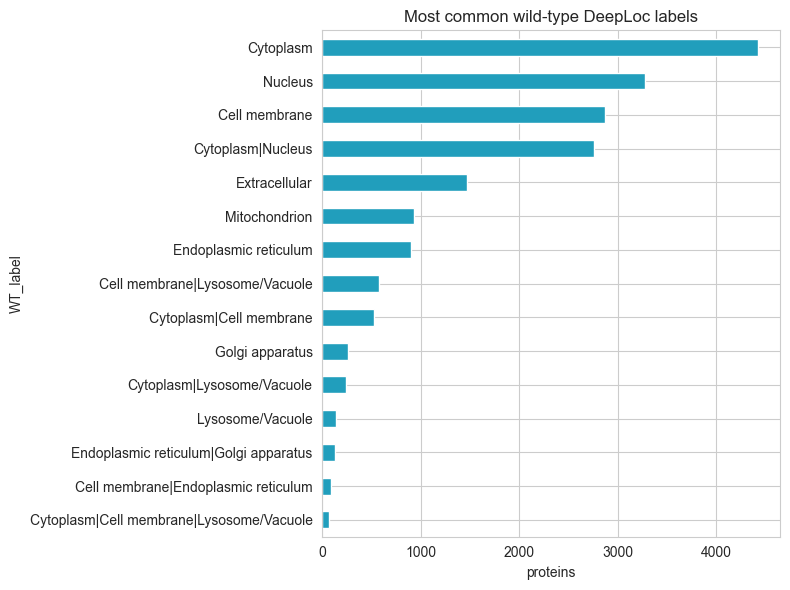

In [4]:
wt = df.drop_duplicates("accession")
top = wt["WT_label"].value_counts().head(15)
top.iloc[::-1].plot.barh(figsize=(8, 6), color="#219ebc")
plt.xlabel("proteins"); plt.title("Most common wild-type DeepLoc labels"); plt.tight_layout(); plt.show()

## How often does a variant change the predicted label?

In [5]:
print(f"Overall label_changed rate: {df['label_changed'].mean():.2%}")
by_cat = df.groupby("category")["label_changed"].agg(["mean", "size"]).sort_values("mean", ascending=False)
by_cat.rename(columns={"mean": "frac_label_changed", "size": "n"})

Overall label_changed rate: 2.18%


,frac_label_changed,n
category,,
nonsense,0.373058,103437
delins,0.170098,5732
ins,0.024878,6351
del,0.014938,21957
dup,0.014570,3020
missense,0.007095,2516708


## How many variants change predicted localization?

Counts, then the fraction with a changed label broken down by variant category (missense, nonsense, etc.).

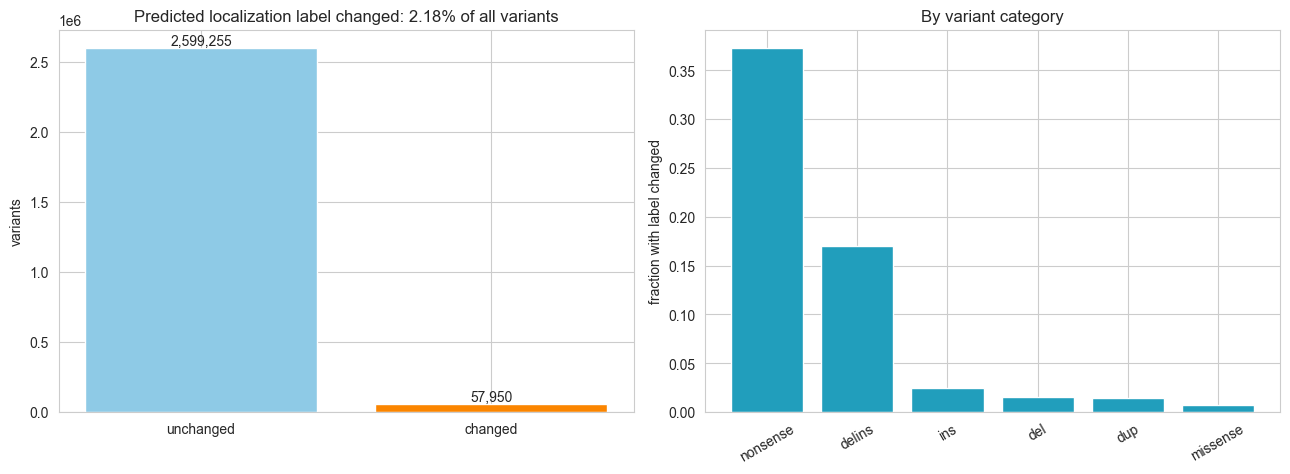

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["label_changed"].map({0: "unchanged", 1: "changed"}).value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[4]])
axes[0].set_ylabel("variants")
axes[0].set_title(f"Predicted localization label changed: {df['label_changed'].mean():.2%} of all variants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

by_cat = df.groupby("category")["label_changed"].mean().sort_values(ascending=False)
axes[1].bar(by_cat.index, by_cat.values, color=PALETTE[1])
axes[1].set_ylabel("fraction with label changed")
axes[1].set_title("By variant category")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## Variant effect (delta) distributions

`DELTA = mutant - WT` probability. Most variants should sit near zero; the tails are the interesting cases (log y-axis).

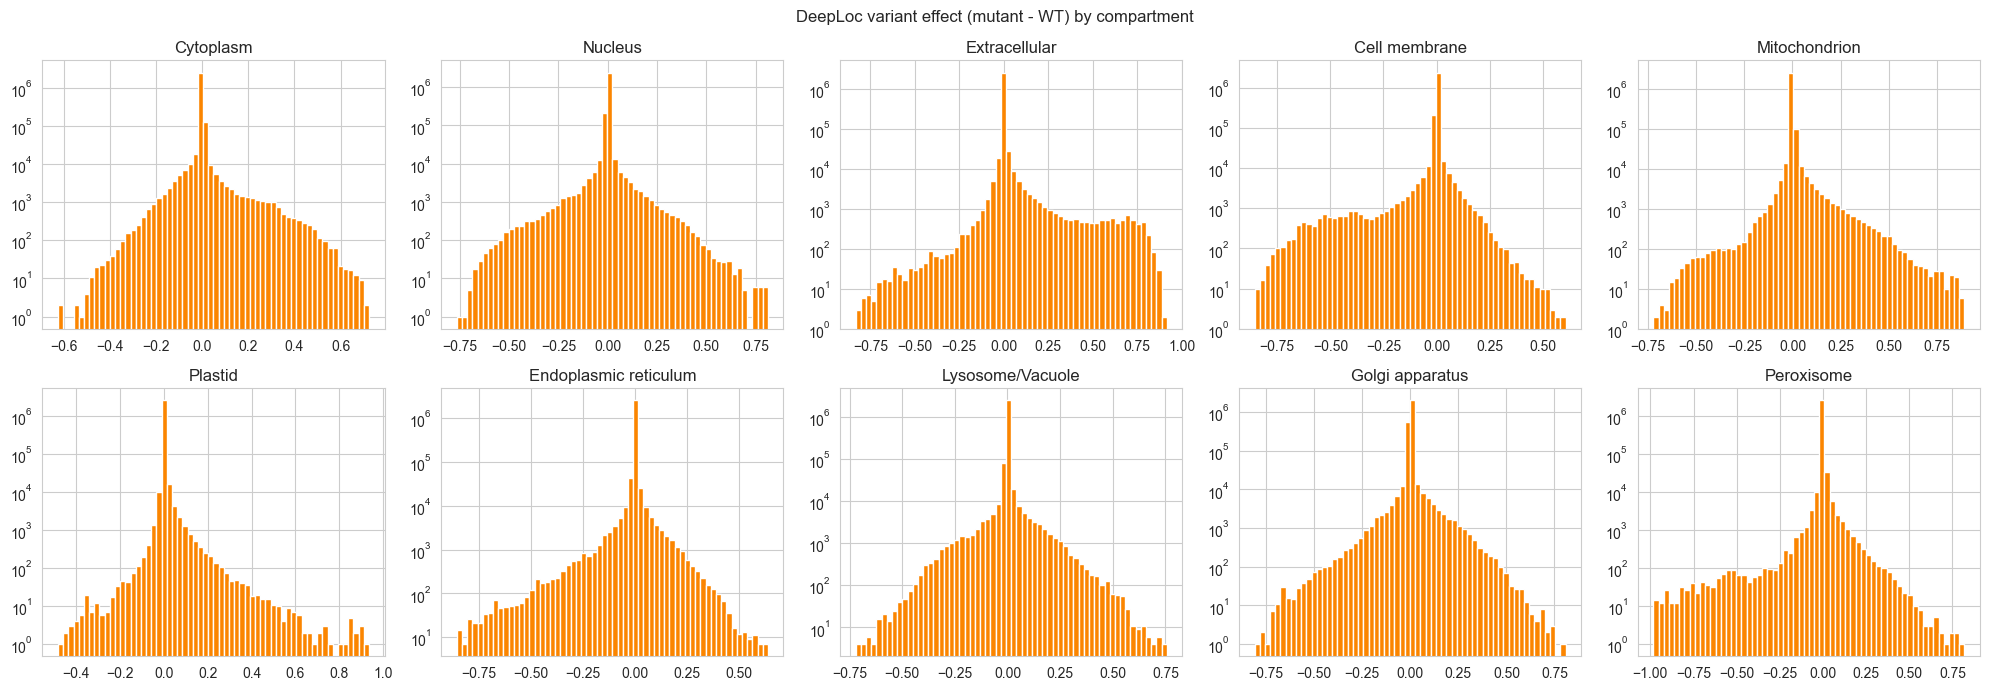

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.flat, LOCS):
    ax.hist(df[f"DELTA_{c}"], bins=60, color="#fb8500"); ax.set_yscale("log"); ax.set_title(c)
fig.suptitle("DeepLoc variant effect (mutant - WT) by compartment"); fig.tight_layout(); plt.show()

## Wild-type label to mutant label transitions

Among variants whose label changed: the most common transitions.

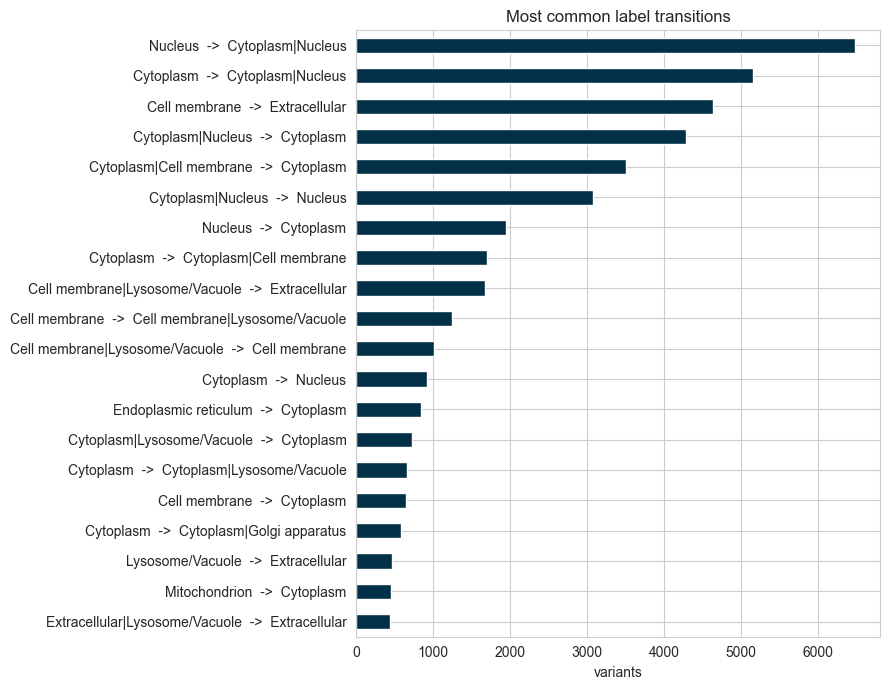

In [8]:
ch = df[df["label_changed"] == 1]
trans = (ch["WT_label"] + "  ->  " + ch["MUT_label"]).value_counts().head(20)
trans.iloc[::-1].plot.barh(figsize=(9, 7), color="#023047")
plt.xlabel("variants"); plt.title("Most common label transitions"); plt.tight_layout(); plt.show()

## Variants with the largest predicted localization shift

Ranked by the largest absolute delta across the 10 compartments.

In [9]:
dcols = [f"DELTA_{c}" for c in LOCS]
mx = df[dcols].abs().max(axis=1)
top = df.loc[mx.sort_values(ascending=False).index[:25]]
top[[ID, GENE, "category", "WT_label", "MUT_label"] + dcols]

,VariationID,GeneSymbol,category,WT_label,MUT_label,DELTA_Cytoplasm,DELTA_Nucleus,DELTA_Extracellular,DELTA_Cell membrane,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome
793487,1960019,ACOX1,nonsense,Peroxisome,Cytoplasm,0.5664,0.1373,0.0285,0.0328,0.2210,-0.0026,-0.3194,-0.1553,-0.0914,-0.9827
510315,1438515,AMACR,nonsense,Peroxisome,Cytoplasm,0.2376,-0.0388,0.0208,0.2092,-0.1245,-0.1435,0.2410,0.2681,0.2499,-0.9816
496624,1394367,AMACR,nonsense,Peroxisome,Cytoplasm,0.1957,0.0070,0.0186,0.3169,-0.1299,-0.1499,0.2359,0.2967,0.2360,-0.9798
857581,2104874,ACOX1,nonsense,Peroxisome,Cytoplasm|Nucleus,0.5438,0.2356,0.0176,0.0195,0.1649,-0.0072,-0.3089,-0.1510,-0.0929,-0.9774
1286749,2695972,ACOX2,nonsense,Peroxisome,Nucleus,0.2547,0.1541,0.1383,-0.0112,0.1898,0.0096,-0.0284,-0.0851,0.0092,-0.9763
1262883,2629268,ACOX2,nonsense,Peroxisome,Cytoplasm|Nucleus,0.3681,0.1705,0.1008,-0.0053,0.1597,0.0275,-0.0610,-0.0444,0.0255,-0.9688
649835,1685498,ACOX1,nonsense,Peroxisome,Cytoplasm,0.5389,0.1128,0.0456,0.0402,0.2771,0.0054,-0.3171,-0.1366,-0.0935,-0.9688
221358,598561,EHHADH,nonsense,Peroxisome,Cytoplasm|Mitochondrion,0.1641,0.2107,0.1942,0.0603,0.3523,-0.0081,0.3377,-0.2200,0.1030,-0.9668
2371273,4371103,CAT,nonsense,Peroxisome,Cytoplasm,0.1951,0.2571,-0.1295,0.0692,0.0418,0.0424,-0.2205,-0.1224,-0.0162,-0.9660
586537,1481363,AMACR,nonsense,Peroxisome,Cytoplasm,0.1518,-0.2023,0.0333,0.2176,-0.3682,-0.0977,0.3134,0.1725,0.1790,-0.9655


## Genes with the most variants that shift localization

Counted as variants with any compartment delta of at least 0.5 in magnitude.

In [10]:
big = df[mx >= 0.5]
print(f"{len(big):,} variants ({len(big)/len(df):.2%}) with |delta| >= 0.5")
big[GENE].value_counts().head(20)

10,568 variants (0.40%) with |delta| >= 0.5


GeneSymbol
USH2A     625
PKD1      418
PKHD1     310
LDLR      242
ADGRV1    209
JAG1      150
CRB1      130
CDH23     130
CDH1      128
FRAS1     116
PCDH15    103
RYR1       98
PEX1       96
ENG        91
NPHS1      90
LRP2       87
PCDH19     84
MPL        64
L1CAM      58
TYR        56
Name: count, dtype: int64

## ClinVar clinical significance vs. predicted localization change

Joins ClinicalSignificance from `clinvar_metadata_lookup.tsv`. If localization changes are functionally meaningful, pathogenic variants should shift more than benign ones.

In [11]:
meta = pd.read_csv("clinvar_metadata_lookup.tsv", sep="\t", usecols=["VariationID", "ClinicalSignificance"]).drop_duplicates("VariationID")
m = df.merge(meta, on="VariationID", how="left")
m["max_abs_delta"] = m[dcols].abs().max(axis=1)
groups = ["Pathogenic", "Likely pathogenic", "Uncertain significance", "Likely benign", "Benign"]
s = m[m["ClinicalSignificance"].isin(groups)]
summary = s.groupby("ClinicalSignificance").agg(n=("max_abs_delta", "size"), label_changed=("label_changed", "mean"),
                                                 median_max_delta=("max_abs_delta", "median"),
                                                 frac_delta_ge_0_5=("max_abs_delta", lambda x: (x >= 0.5).mean())).loc[groups]
summary

,n,label_changed,median_max_delta,frac_delta_ge_0_5
ClinicalSignificance,,,,
Pathogenic,80012,0.270034,0.0912,0.070502
Likely pathogenic,55674,0.120487,0.0065,0.033175
Uncertain significance,2162920,0.008941,0.0023,0.000427
Likely benign,104152,0.006020,0.0018,0.000298
Benign,31014,0.007029,0.0018,0.000742


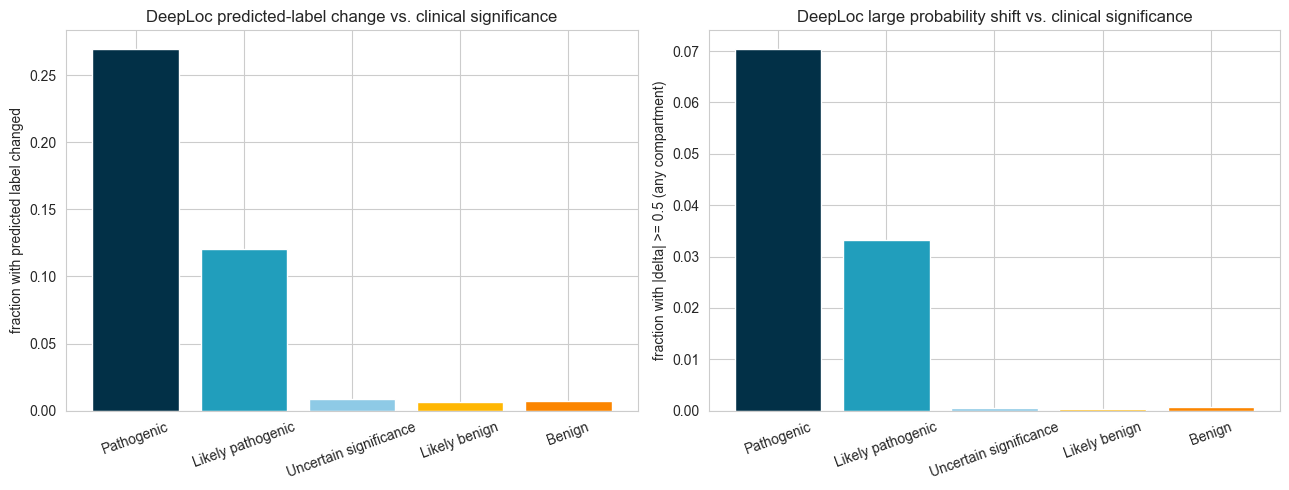

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [PALETTE[2], PALETTE[1], PALETTE[0], PALETTE[3], PALETTE[4]]
axes[0].bar(summary.index, summary["label_changed"], color=colors)
axes[0].set_ylabel("fraction with predicted label changed")
axes[0].set_title("DeepLoc predicted-label change vs. clinical significance")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(summary.index, summary["frac_delta_ge_0_5"], color=colors)
axes[1].set_ylabel("fraction with |delta| >= 0.5 (any compartment)")
axes[1].set_title("DeepLoc large probability shift vs. clinical significance")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

/var/folders/pf/8s82tkcj2z92hkmhf8vknhh80000gn/T/ipykernel_85639/496002890.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=s, x="ClinicalSignificance", y="max_abs_delta", order=groups, showfliers=False, palette=PALETTE)


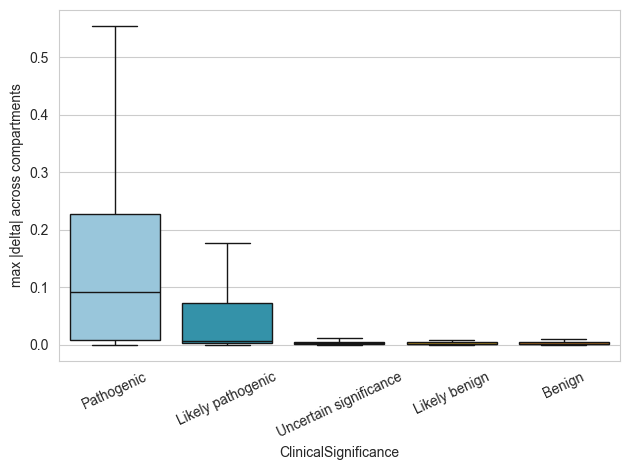

In [13]:
sns.boxplot(data=s, x="ClinicalSignificance", y="max_abs_delta", order=groups, showfliers=False, palette=PALETTE)
plt.xticks(rotation=25); plt.ylabel("max |delta| across compartments"); plt.tight_layout(); plt.show()